<a href="https://colab.research.google.com/github/jppeirce/DSC210-Foundations-of-Data-Science/blob/main/ClassNotebooks/07-exploratory_data_analysis/07-exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 7: Exploratory Data Analysis

**DSC 210 Foundations of Data Science**

References:
- [Hands-on Introduction to Data Science with Python](https://florian-huber.github.io/data_science_course/) (CC BY-NC-SA 4.0), especially the chapters on *Data Cleaning and Preprocessing* and *Statistical Measures and Distributions*
- [pandas documentation](https://pandas.pydata.org/docs/) and [seaborn documentation](https://seaborn.pydata.org/)
- John W. Tukey, *Exploratory Data Analysis* (1977), the book that gave this subject its name

```
ASK  ->  GET  ->  [ EXPLORE ]  ->  MODEL  ->  COMMUNICATE
```

*Last major revision: 2026-10-04*

In Module 6 we learned to **GET** data into a DataFrame and to select, filter, and sort it. Today we put those tools to work on the stage they were built for: **EXPLORE**.

## Key Concepts

- Explain the purpose of exploratory data analysis, and what it is not
- Distinguish numerical, categorical, and datetime variables, and repair mis-typed columns
- Inspect a dataset's structure with `head`, `shape`, `info`, and `describe`
- Compute and interpret descriptive statistics, and read a histogram, boxplot, and scatterplot
- Identify missing values, duplicates, impossible values, and outliers, and document rather than fix them
- Keep a running question log, and ask the new question each answer creates, which is what makes EDA a loop

Our running dataset is a sample of **6,433 real taxi rides in New York City** from March 2019. One dataset for the whole module: by the end you will know these taxis uncomfortably well. :)

---
## 1. What is Exploratory Data Analysis?
---

### 1.1 The temptation to skip ahead

Here is a situation you will be in many times in your career. Someone hands you a dataset and a question.

For example, you are given a dataset of New York taxi rides and asked: *"Are riders tipping less than they used to?"*

The temptation is to compute an average tip, or to feed the data straight into a model. Resist it. At this moment you do not know:

- what a row in this dataset even represents,
- whether the columns mean what their names suggest,
- whether values are missing, duplicated, or impossible,
- whether the data can answer the question at all.

An analysis built on data you do not understand will happily produce numbers. They will just be the wrong numbers, delivered with great confidence.

Remember: <img src="https://raw.githubusercontent.com/jppeirce/DSC210-Foundations-of-Data-Science/main/ClassNotebooks/07-exploratory_data_analysis/gigo.png?raw=true" width="400">

This is also why, in practice, getting, understanding, and preparing data usually costs far more time, sweat, and tears than the polished results people see at the end:

<img src="https://raw.githubusercontent.com/jppeirce/DSC210-Foundations-of-Data-Science/main/ClassNotebooks/07-exploratory_data_analysis/fig_data_acquisition_problems.png?raw=true" width="800">

**Definition.** *Exploratory Data Analysis (EDA)* is the process of getting to know a dataset, through summaries, tables, and pictures, **before** drawing conclusions or building models.

The statistician John Tukey, who wrote the book on EDA in 1977, put the spirit of it this way: *"The greatest value of a picture is when it forces us to notice what we never expected to see."*

### 1.2 What EDA is, and what it is not

EDA **is**:

- asking simple questions and answering them with small computations,
- drawing quick, unpolished plots and actually looking at them (for patterns or questions),
- being professionally suspicious of every column (variable),
- keeping a running list of findings and new questions.

EDA **is not**:

- testing a hypothesis (that is formal inference, later in the course),
- building a predictive model (that is the MODEL stage),
- making publication-quality graphics (that is COMMUNICATE).

The goal of EDA is *understanding*: a short list of what you learned, what worries you, and what you want to ask next.

#### The loop we will run

EDA is not a fixed sequence of steps. It is a loop:

```
    ask a question
        |
        v
  compute or plot something
        |
        v
  notice something unexpected   ->   (write it down!)
        |
        v
  refine the question, ask a new one
        |
        v
       repeat
```

To make the loop visible, this module keeps a **Question log**. Every oddity we notice becomes a numbered question (Q1, Q2, ...), and at the end of each section we record which questions were answered and which new ones appeared. Watch how often an answer creates the next question.

Note: although EXPLORE has its own box in our pipeline, exploration actually happens at every stage. We explore when data arrives (do the types look right?), while cleaning (which values are suspicious?), while modeling (which points have outsized influence?), and while communicating (which picture tells the story?).

### 1.3 New York City taxi rides

For this module, assume that you are a new data analyst at the NYC Taxi and Limousine Commission (TLC), the agency that regulates the city's taxis. The TLC publishes records of every taxi trip in the city; our dataset is a sample of **6,433 rides from March 2019** that ships with the seaborn library.

Two kinds of cabs appear in the data:
- **Yellow cabs** may pick up street hails anywhere in the city.
- **Green cabs** (the "boro taxis") were introduced to improve service outside the Manhattan core; they may only pick up street hails in upper Manhattan and the outer boroughs.

Each row is **one taxi ride**: when and where it started and ended, how far it went, what it cost, and how it was paid for.

#### **Activity 7.1**

Your boss at the TLC asks the question from Section 1.1: *"Are riders tipping less than they used to?"*

This is **Q1** in our Question log, and it is the question this module works toward. We will come back to it at the end.

Before we write a single line of code, pause and list **three things you would want to know about this dataset** before trusting any answer that comes out of it. Think about where the data came from, what exactly got recorded, and what could quietly go wrong.

---
## 2. Loading and Inspecting Data
---

**Look before you leap:** The first fifteen minutes with any new dataset follows the same ritual.

In [1]:
# RUN-TOGETHER
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')   # a clean default look for all plots

In [2]:
# RUN-TOGETHER
# The dataset lives at a public URL, just like a file someone emailed you.
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv'
taxis = pd.read_csv(url)

# ALWAYS check that it loaded the way you expected.
taxis.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


### 2.1 A guided tour of the columns

`head()` shows the first five rows. Lets investigate:

| Column | Meaning |
| --- | --- |
| `pickup`, `dropoff` | date and time the ride began and ended |
| `passengers` | number of riders in the cab |
| `distance` | trip length in miles |
| `fare` | metered fare, in dollars |
| `tip` | recorded tip, in dollars |
| `tolls` | bridge and tunnel tolls, in dollars |
| `total` | total amount charged, in dollars |
| `color` | `yellow` or `green` cab |
| `payment` | `credit card` or `cash` |
| `pickup_zone`, `dropoff_zone` | neighborhood names |
| `pickup_borough`, `dropoff_borough` | the NYC boroughs |

Even five rows generate observations. The `pickup` column *looks* like a date and time, but is it stored that way? One of the five tips is exactly 0. Is that common, or a fluke? Both go on our list of questions.

In [3]:
# RUN-TOGETHER
# head() shows the top of the file... which may not be typical of the file.
taxis.tail()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn
6432,2019-03-13 19:31:22,2019-03-13 19:48:02,1,3.85,15.0,3.36,0.0,20.16,green,credit card,Boerum Hill,Windsor Terrace,Brooklyn,Brooklyn


In [4]:
# RUN-TOGETHER
# A RANDOM peek is more honest than the top or bottom.
# random_state pins the randomness so we all see the same five rows.
taxis.sample(5, random_state=210)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
1624,2019-03-27 22:36:16,2019-03-27 22:41:36,1,0.68,5.0,1.76,0.0,10.56,yellow,credit card,Midtown East,Midtown East,Manhattan,Manhattan
4108,2019-03-22 21:30:40,2019-03-22 21:42:17,1,1.36,8.5,1.00,0.0,13.30,yellow,credit card,Sutton Place/Turtle Bay North,Clinton East,Manhattan,Manhattan
4756,2019-03-09 23:55:11,2019-03-10 00:12:24,1,1.90,12.0,3.15,0.0,18.95,yellow,credit card,West Village,Two Bridges/Seward Park,Manhattan,Manhattan
4746,2019-03-12 07:06:07,2019-03-12 07:06:21,1,1.30,2.5,0.00,0.0,5.80,yellow,NaN,Meatpacking/West Village West,Meatpacking/West Village West,Manhattan,Manhattan
6090,2019-03-14 13:32:03,2019-03-14 13:45:52,1,2.42,12.0,0.00,0.0,12.80,green,credit card,Ozone Park,Howard Beach,Queens,Queens


Compare the three peeks. `head()` shows only **yellow** cabs and `tail()` shows only **green** cabs. That is not a coincidence: this file is sorted by cab color, with every yellow ride first and every green ride after them. Someone who only ever looked at `head()` might never learn that green cabs exist.

That is why we bother with `sample()`. Files often arrive sorted by date, by ID, by category, or by something invisible to you. Five random rows is a small peek, but it is a more honest portrait than the first or last five.

**Quick look:** in your sample of five, is anything surprising? Any zeros, blanks, or odd combinations?

#### **Activity 7.2 (predict, then run)**

Before running the next cell, write down your guesses:

a. How many **rows** does `taxis` have? (You have seen the number already today.)

b. How many **columns**?

Then fill in the blanks and check yourself. Recall from Module 6 that `shape` is an *attribute*, not a method: no parentheses.

In [5]:
# Activity 7.2
print('shape (rows, cols):', taxis.shape)
print()
print('columns:', list(taxis.columns))

shape (rows, cols): (6433, 14)

columns: ['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls', 'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']


In [6]:
# RUN-TOGETHER
taxis.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pickup           6433 non-null   str    
 1   dropoff          6433 non-null   str    
 2   passengers       6433 non-null   int64  
 3   distance         6433 non-null   float64
 4   fare             6433 non-null   float64
 5   tip              6433 non-null   float64
 6   tolls            6433 non-null   float64
 7   total            6433 non-null   float64
 8   color            6433 non-null   str    
 9   payment          6389 non-null   str    
 10  pickup_zone      6407 non-null   str    
 11  dropoff_zone     6388 non-null   str    
 12  pickup_borough   6407 non-null   str    
 13  dropoff_borough  6388 non-null   str    
dtypes: float64(5), int64(1), str(8)
memory usage: 703.7 KB


`info()` is dense, so read it top to bottom, three questions at a time:

1. **How much data?** 6,433 rows, 14 columns.
2. **Is anything missing?** Compare each Non-Null Count to 6,433. Look at `payment`: 6,389 non-null. That means **44 rides have no recorded payment type**. Same story for the zone and borough columns. 
3. **How is each column stored?** The Dtype column says `pickup` and `dropoff` are stored as `str`, meaning text. (Versions of pandas before 3.0 print `object` here instead; for our purposes it means the same thing.) But they are clearly dates and times. A column can *look* like a date and be stored as text, and text cannot be subtracted, sorted by clock, or grouped by hour. We will fix this in Section 3.

In [7]:
# RUN-TOGETHER
# Descriptive statistics for every NUMERIC column.
taxis.describe()

,passengers,distance,fare,tip,tolls,total
count,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
std,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570
min,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000


`describe()`: For each numeric column we get the count of non-missing values, the mean, the standard deviation, and the five-number summary (min, 25%, 50%, 75%, max). Note:

- **`fare`:** the mean is about 13.09 dollars but the median (the 50% row) is 9.50. When the mean sits well above the median, a long right tail of expensive rides is pulling it up. Remember from the elementary statistics...the mean is affected by extreme values, the median does not.
- **`fare` again:** the maximum is 150 dollars, more than fifteen times the median. Real, or an error? We do not know yet. Make a note of it.
- **`passengers`:** the minimum is **0**. A taxi ride with nobody in it? Write that down too.

Each oddity goes into our Question log as a *question*. Also notice what `describe()` did **not** show: the text columns. It summarizes numeric columns by default.

In [8]:
# RUN-TOGETHER
# The same idea for the NON-numeric columns.
taxis.describe(exclude='number')

,pickup,dropoff,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
count,6433,6433,6433,6389,6407,6388,6407,6388
unique,6414,6425,2,2,194,203,4,5
top,2019-03-24 00:12:23,2019-03-02 00:58:26,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
freq,2,2,5451,4577,230,245,5268,5206


For text columns we get: `count` (non-missing), `unique` (number of distinct values), `top` (most common value), and `freq` (how often the top value appears). Manhattan is the top pickup borough with 5,268 of 6,407 recorded pickups; this sample is very Manhattan-heavy, which matters when we generalize.

Here is a small puzzle hiding in plain sight: `pickup_borough` has **4** unique values but `dropoff_borough` has **5**. Some borough receives rides but never produces them, at least in this sample.

#### **Activity 7.3**

Using only commands from this section plus `value_counts()` from Module 6, answer:

a. How many rides are missing a `dropoff_zone`?

b. What was the largest `total` charged?

c. What is the **median** trip `distance`?

d. Which borough appears in `dropoff_borough` but never in `pickup_borough`?

One new tool for part (a): `taxis['col'].isna()` returns True/False for every entry, and chaining `.sum()` counts the Trues. (We come back to this.)

In [9]:
# Activity 7.3
# a. missing dropoff_zone: total rows minus non-null count, or use isna
print('missing dropoff_zone:', taxis['dropoff_zone'].isna().sum())

# b. largest total fares
print('largest total:', taxis['total'].max())

# c. median distance
print('median distance:', taxis['distance'].median())

# d. compare the categories of the two borough columns
print(taxis['pickup_borough'].value_counts())
print(taxis['dropoff_borough'].value_counts())

missing dropoff_zone: 45
largest total: 174.82
median distance: 1.64
pickup_borough
Manhattan    5268
Queens        657
Brooklyn      383
Bronx          99
Name: count, dtype: int64
dropoff_borough
Manhattan        5206
Queens            542
Brooklyn          501
Bronx             137
Staten Island       2
Name: count, dtype: int64


#### Question log (opened at the end of Section 2)

Fifteen minutes with the data and we already have more questions than answers. That is a good sign. Here is our log so far:

| # | Question | Raised in | Status |
| --- | --- | --- | --- |
| Q1 | Are riders tipping less than they used to? (the boss's question) | Activity 7.1 | open |
| Q2 | `pickup` and `dropoff` are stored as text. Can we treat them as times? | `head()`, `info()` | open |
| Q3 | Some tips are exactly 0. How common is that, and why? | `head()` | open |
| Q4 | 44 rides have no payment type, and 26 to 45 rides lack a zone or borough. Is the missingness random or systematic? | `info()` | open |
| Q5 | The mean fare (13.09 dollars) sits well above the median (9.50), and the maximum is 150 dollars. Is there a long tail? Is 150 dollars real? | `describe()` | open |
| Q6 | The minimum of `passengers` is 0. A taxi ride with nobody in it? | `describe()` | open |
| Q7 | Why does `dropoff_borough` have 5 values but `pickup_borough` only 4? | `describe(exclude='number')` | closed in Activity 7.3(d) |

Keep your own copy of this log as you work. At the end of each section we will update it.

---
## 3. Understanding Variables
---

`info()` told us how each column is *stored*. But to choose the right tool for a column, we need to know what kind of thing it *is*. Taking the average of `fare` makes sense. Taking the average of `pickup_borough` is nonsense. Counting the distinct values of `payment` is useful; counting the distinct values of `fare` is not. The type of a variable determines which questions are even well-posed.

#### **Activity 7.4 (Think-Pair-Share, before reading 3.1)**

Start from what you remember from Elementary Statistics; Section 3.1 will let you check your answers.

With a partner, classify **every** column of `taxis` as numerical, categorical, or datetime, and flag any column that could defensibly go two ways.

Then take a side and defend it: is `passengers` numerical or categorical?

### 3.1 Three families of variables

**Numerical (quantitative)** variables are measured amounts. Arithmetic on them is meaningful.

- *Continuous:* can take any value in a range: `distance`, `fare`, `tip`.
- *Discrete:* whole-number counts: `passengers`.

**Categorical (qualitative)** variables place each observation into a group.

- *Nominal:* groups with no natural order: `color`, `payment`, `pickup_borough`.
- *Ordinal:* groups with a natural order (small < medium < large). Our taxi data has no ordinal column. But if customers rated their ride: not satisfactory/satisfactory/great, then their ratings would be an ordinal categorical variable.

**Datetime** variables are points in time: `pickup`, `dropoff`. They deserve their own family because time has rich structure: order, durations, hours of the day, days of the week, seasons.

A rough matching of families to tools, which is really the table of contents for the rest of this module:

| Family | Typical summaries | Typical pictures |
| --- | --- | --- |
| Numerical | mean, median, spread, quantiles | histogram, boxplot |
| Categorical | counts, proportions | bar chart |
| Datetime | ranges, durations | counts over time |

### 3.2 The dtype is not destiny

The pandas dtype tells you how a column is *stored*, not what it *means*, and the two can disagree:

- `pickup` is stored as text but means a datetime.
- A ZIP code column would be stored as an integer but means a category (averaging ZIP codes is nonsense).
- `passengers` is stored as an integer and could reasonably be treated as a count *or* as a grouping category, depending on the question.

Part of EDA is noticing these mismatches and correcting the ones that block your analysis.

In [10]:
# RUN-TOGETHER
taxis.dtypes

pickup                 str
dropoff                str
passengers           int64
distance           float64
fare               float64
tip                float64
tolls              float64
total              float64
color                  str
payment                str
pickup_zone            str
dropoff_zone           str
pickup_borough         str
dropoff_borough        str
dtype: object

### 3.3 Repairing the datetime columns

Right now `taxis['dropoff'] - taxis['pickup']`, which *should* give the ride duration, would fail: you cannot subtract one string from another. The fix is `pd.to_datetime()`, which parses text into true datetime values.

In [11]:
# RUN-TOGETHER
taxis['pickup'] = pd.to_datetime(taxis['pickup'])
taxis['dropoff'] = pd.to_datetime(taxis['dropoff'])

taxis.dtypes.head(3)   # confirm the repair took

pickup        datetime64[us]
dropoff       datetime64[us]
passengers             int64
dtype: object

Now that the times are real times, we can ask a question that was impossible a minute ago: **what period does this data actually cover?** The minimum and maximum of a datetime column are its earliest and latest moments.

In [12]:
# RUN-TOGETHER
# min() and max() work on datetimes: the earliest and latest pickup.
print('first pickup:', taxis['pickup'].min())
print('last pickup: ', taxis['pickup'].max())

first pickup: 2019-02-28 23:29:03
last pickup:  2019-03-31 23:43:45


The data runs from late on February 28 to the night of March 31, 2019: one month, plus a single ride that started about half an hour before March did. (A file described as "March" with a February ride in it is a small reminder to check labels rather than trust them.)

Now look back at **Q1**. The boss asked whether riders are tipping *less than they used to*. That is a question about change over time, and this dataset holds **one month**. There is no earlier period to compare against, so no analysis of this file can answer Q1 as asked. We will keep exploring, because there is more to learn about what this data *can* say about tips, but this is our first major finding, and it came from checking a date range.

Now the payoff. With genuine datetimes we can *derive new columns* (the Module 6 move) that unlock whole families of questions: How long did rides take? What time of day do people ride? Which day of the week is busiest?

The `.dt` accessor reaches into a datetime column and pulls out parts: `.dt.hour`, `.dt.day_name()`, and more.

In [13]:
# RUN-TOGETHER
# Duration in minutes: subtract, then convert the result to seconds, then minutes.
taxis['duration_min'] = (taxis['dropoff'] - taxis['pickup']).dt.total_seconds() / 60

# Extract the hour (0-23) and the weekday name of each pickup.
taxis['pickup_hour'] = taxis['pickup'].dt.hour
taxis['pickup_day'] = taxis['pickup'].dt.day_name()

taxis[['pickup', 'duration_min', 'pickup_hour', 'pickup_day']].head()

,pickup,duration_min,pickup_hour,pickup_day
0,2019-03-23 20:21:09,6.250000,20,Saturday
1,2019-03-04 16:11:55,7.083333,16,Monday
2,2019-03-27 17:53:01,7.400000,17,Wednesday
3,2019-03-10 01:23:59,25.866667,1,Sunday
4,2019-03-30 13:27:42,9.533333,13,Saturday


Three new columns, three new dimensions of the dataset, and none of them existed in the file.

**A large part of EDA is manufacturing the variable you actually want from the ones you were given.**  
- Commonly called feature engineering or feature creation.

#### **Activity 7.5**

Before you run anything: guess the median ride duration in minutes, and guess the busiest day of the week. Then check:

a. Compute the **median** of `duration_min`.

b. What **proportion** of rides carry 2 or more passengers? Use the trick that the mean of a True/False column is the proportion of Trues (True counts as 1, False as 0).

c. Which day of the week has the most rides?

d. Before you announce your answer to (c), look at a calendar for March 2019. Which days of the week appear **five** times that month, and which appear only four? Does that change how you should compare the days?

In [15]:
# Activity 7.5
# a. median duration
print('median duration (min):', taxis['duration_min'].median())

# b. proportion of shared rides: mean of a boolean column
mask = taxis['passengers'] >= 2
print('share with 2+ passengers:', mask.mean().round(3))

# c. rides per weekday
print(taxis['pickup_day'].value_counts())

# d. your answer, as a comment:
#

median duration (min): 10.9
share with 2+ passengers: 0.258
pickup_day
Friday       1115
Saturday     1046
Wednesday     966
Thursday      905
Sunday        868
Tuesday       825
Monday        708
Name: count, dtype: int64


#### Question log update (end of Section 3)

- **Closed Q2.** `pd.to_datetime()` repaired `pickup` and `dropoff`, and the repair let us derive duration, hour, and weekday.
- **New evidence on Q1.** The data covers a single month, so it cannot show whether tipping has changed over time.
- **Opened:** nothing new, but Activity 7.5(d) is a reminder that even a simple count ("which day is busiest?") can hide a comparison problem.

---
## 4. Looking at One Variable at a Time
---

We now know what the columns are. The next step is to understand each interesting variable **on its own** before we study how variables relate. Statisticians call this *univariate* analysis, and doing it first is a discipline: if you do not know what `fare` looks like alone, you cannot recognize when something strange happens to it in a scatterplot.

The plan follows our variable families: categorical first (frequency tables and bar charts), then numerical (summary statistics, histograms, boxplots), then our derived time variables.

### 4.1 Categorical variables: frequency tables

For a categorical column the fundamental question is: **how often does each category occur?** We use `value_counts()` from Module 6, and `normalize=True` converts counts to proportions.

In [16]:
# RUN-TOGETHER
print(taxis['color'].value_counts())
print()
print(taxis['payment'].value_counts(normalize=True).round(3))

color
yellow    5451
green      982
Name: count, dtype: int64

payment
credit card    0.716
cash           0.284
Name: proportion, dtype: float64


Yellow cabs dominate the sample (5,451 of 6,433, about 85%), and roughly 72% of rides with a recorded payment were paid by credit card.

One caution: by default `value_counts()` silently **drops missing values**. The payment proportions above are proportions *of the 6,389 recorded payments*, not of all 6,433 rides. Passing `dropna=False` would show the missing group as its own row.

A frequency table becomes a **bar chart** when you want your audience to compare sizes at a glance.

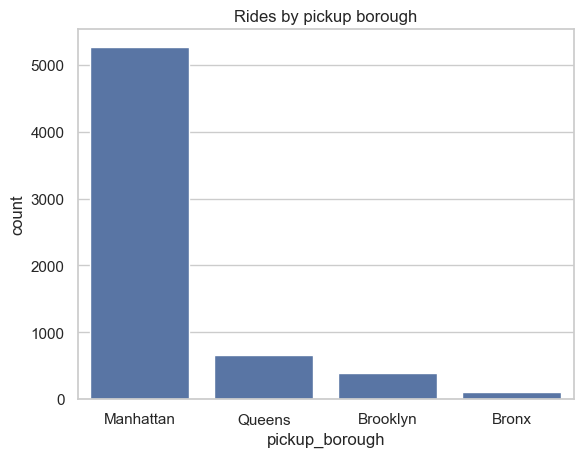

In [17]:
# RUN-TOGETHER
sns.countplot(data=taxis, x='pickup_borough',
              order=taxis['pickup_borough'].value_counts().index)
plt.title('Rides by pickup borough')
plt.show()

The bar chart is the frequency table drawn as a picture, with the bars sorted so the eye can rank them instantly. The story: this dataset overwhelmingly describes **Manhattan** pickups. Whatever we conclude about "NYC taxis" today is mostly a conclusion about Manhattan taxis, with a side of Queens. Keep that in the findings list.

### 4.2 Numerical variables: histograms

For a numerical column, a frequency table of exact values is useless (almost every `fare` is different). Instead we ask about the **distribution**: which ranges of values are common, which are rare, and what shape the whole thing makes.

The **histogram** answers this by chopping the number line into bins and counting how many observations land in each.

**Predict first:** sketch, in the air or on paper, the shape you expect for `distance`. Symmetric bell? Flat? Lopsided?

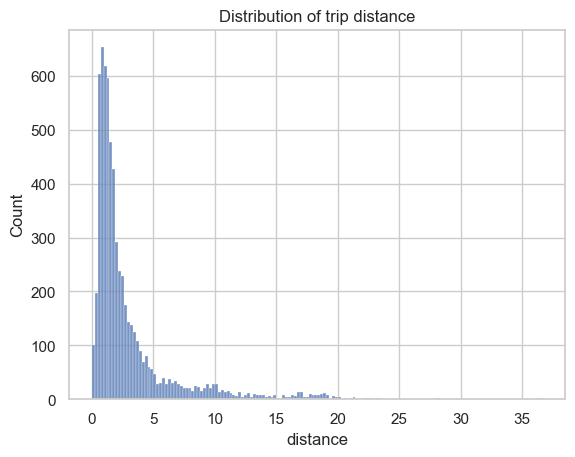

In [18]:
# RUN-TOGETHER
sns.histplot(data=taxis, x='distance')
plt.title('Distribution of trip distance')
plt.show()

Not a bell. The mass piles up below about 3 miles and a long tail stretches to the right, out past 30. This shape is called **right-skewed** (the tail points right).

Skew explains a mystery from Section 2: mean distance is 3.02 miles but the median is 1.64. The handful of very long trips drag the mean upward while the median stands firm. For skewed variables, *median and quartiles are usually the more honest summary*.

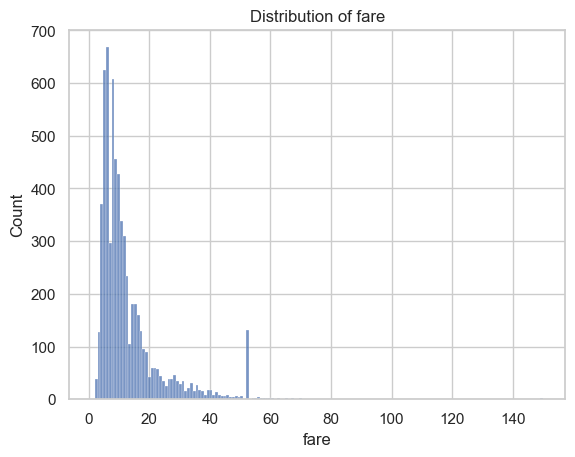

In [19]:
# RUN-TOGETHER
sns.histplot(data=taxis, x='fare')
plt.title('Distribution of fare')
plt.show()

`fare` tells the same right-skewed story: mean 13.09 above median 9.50, long expensive tail. But look closely around **50 dollars**: a little bump interrupts the smooth decay. Fares of about 52 dollars are more common than fares of 40 or 60. A smooth process should not do that.

Into the log it goes as **Q8**: *why would many unrelated rides cost almost exactly the same, fairly large amount?*

(This histogram also answers half of Q5: the mean fare sits above the median because of the long right tail.)

#### The bins are a choice

A histogram depends on how many bins you cut the axis into, and the default is generally nobody's friend. Watch the same variable at two extremes.

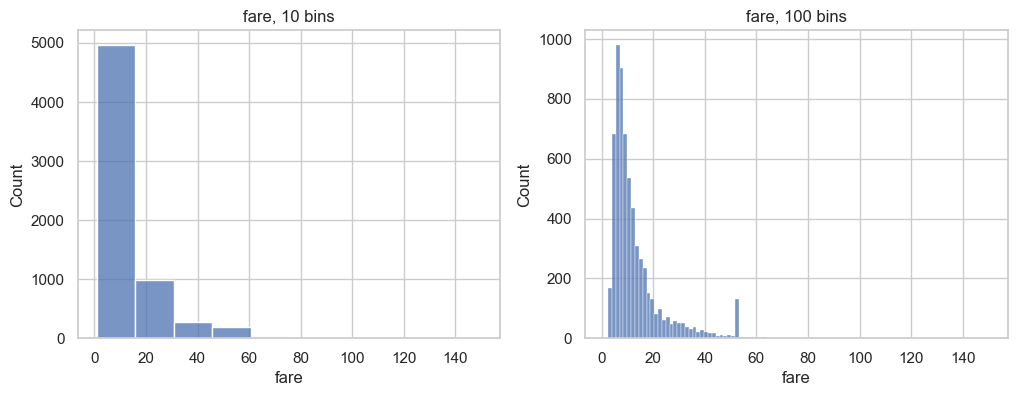

In [20]:
# RUN-TOGETHER
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=taxis, x='fare', bins=10, ax=axes[0])
axes[0].set_title('fare, 10 bins')
sns.histplot(data=taxis, x='fare', bins=100, ax=axes[1])
axes[1].set_title('fare, 100 bins')
plt.show()

Ten bins melt the 52-dollar bump away entirely; one hundred bins make it unmistakable but shred the rest into noise. Neither is "the truth". The practical habit: **always try two or three bin counts** before trusting what a histogram tells you.

### 4.3 Boxplots: the five-number summary as a picture

The histogram shows the whole shape; the **boxplot** compresses a distribution into its landmarks

- the line inside the box is the **median**,
- the box spans the **first to third quartile** (the middle 50% of the data, whose width is the interquartile range, IQR),
- the whiskers extend to the most extreme points within **1.5 × IQR** of the box,
- anything beyond the whiskers is drawn as an individual **flagged point**.

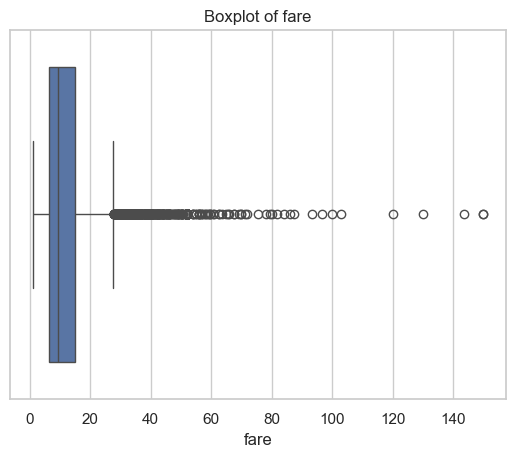

In [21]:
# RUN-TOGETHER
sns.boxplot(data=taxis, x='fare')
plt.title('Boxplot of fare')
plt.show()

Same variable, same story, new lens: the box is squashed against the left (half of all fares live between 6.50 and 15 dollars) while a parade of flagged points marches off to the right.

Are those flagged points errors? **Not necessarily.**

Note: the histogram shows *shape*, the boxplot shows *landmarks and flags*. We will usually want both.

### 4.4 The time variables

Our derived columns are variables too, and they answer a question every city planner cares about: **when do people take taxis?**

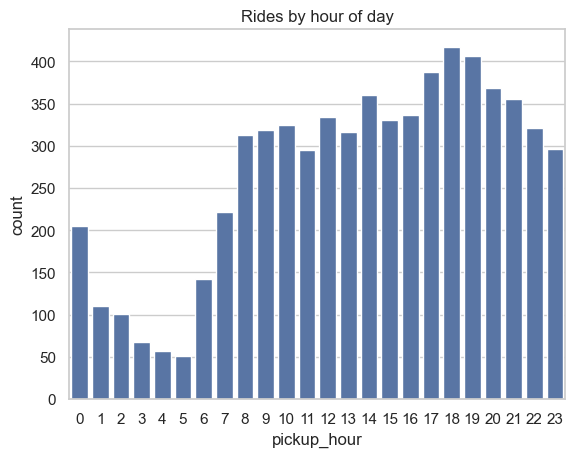

In [22]:
# RUN-TOGETHER
sns.countplot(data=taxis, x='pickup_hour')
plt.title('Rides by hour of day')
plt.show()

Read it like a day in the life of the city: the quietest hours are 3 to 5 in the morning (about 50 to 70 rides each), demand climbs through the morning, and the peak is the evening, 6 to 8 pm, at roughly 400 rides per hour.

And here is EDA doing its job, because a good plot generates the *next* question: the 4 and 5 am rides are few, but are they **different in kind**? Who takes a taxi at 4:30 am? That becomes **Q9**.

#### **Activity 7.6**

Your turn to run the full univariate playbook on a fresh variable: **`tip`**.

a. Compute its descriptive statistics with `describe()`.

b. Draw a histogram.

c. Draw a boxplot.

d. In two sentences, in your own words: what shape is this distribution, what is a typical tip, and is there anything odd?

There *is* something odd, and it is not new: it is **Q3** from Section 2 coming back with much stronger evidence. When you find it, sharpen Q3 in your log with a number. We will solve it in Section 5.

count    6433.00000
mean        1.97922
std         2.44856
min         0.00000
25%         0.00000
50%         1.70000
75%         2.80000
max        33.20000
Name: tip, dtype: float64


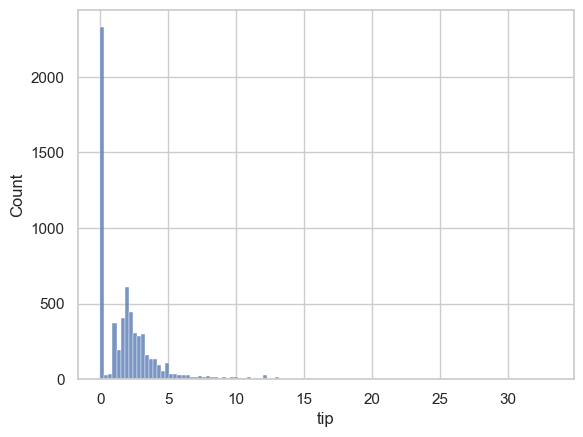

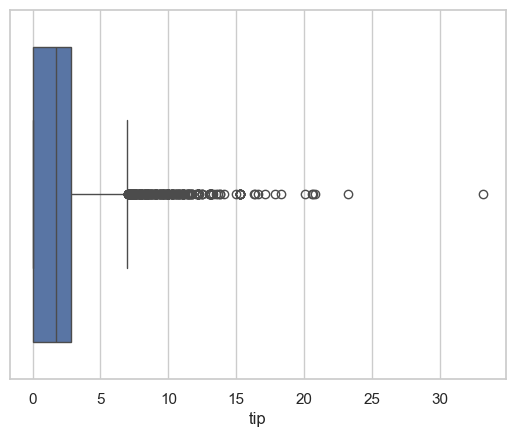

In [23]:
# Activity 7.6
# a. summary statistics
print(taxis['tip'].describe())

# b. histogram
sns.histplot(data=taxis, x= 'tip')
plt.show()

# c. boxplot
sns.boxplot(data=taxis, x='tip')
plt.show()

# d. Your two sentences, as a comment:
#

#### Question log update (end of Section 4)

- **Half of Q5 closed.** The mean fare sits above the median because fares are right-skewed (a long tail of expensive rides). Whether the 150-dollar maximum is real is still open.
- **Q3 sharpened.** In Activity 7.6 the 25th percentile of `tip` is 0, so at least a quarter of all rides record a tip of exactly 0. That is far too many to be a fluke.
- **Opened Q8:** why is there a bump in fares near 52 dollars?
- **Opened Q9:** are the 4 and 5 am rides different in kind from daytime rides?

---
## 5. Looking at Relationships
---

Every variable has now had its solo. But the questions people actually pay data scientists to answer live **between** variables, and most of our open questions are relationship questions: Q8 (the 52-dollar bump), Q9 (the 4 am riders), and Q3 (the zero tips).

We start with fares, for a reason that serves Q1: tips are usually figured as a percentage of the fare, so before we can say anything sensible about tips we need to understand what drives the price of a ride. Three candidate explanations are worth checking:

1. Longer trips cost more (`distance` vs `fare`).
2. More passengers cost more (`passengers` vs `fare`).
3. Prices differ by borough (`pickup_borough` vs `fare`).

These are candidates to *look at*, not hypotheses to formally test; testing comes later in the course.

Each candidate pairs two variables, and the *types* of the pair determine the tool.
- Numerical with numerical: scatterplot.
- Categorical with numerical: group summaries.
- Categorical with categorical: crosstab.

### 5.1 Two numerical variables: the scatterplot

A **scatterplot** puts one variable on each axis and one dot per observation. It is the single most information-dense plot in this course: shape, strength, direction, and exceptions, all in one picture.

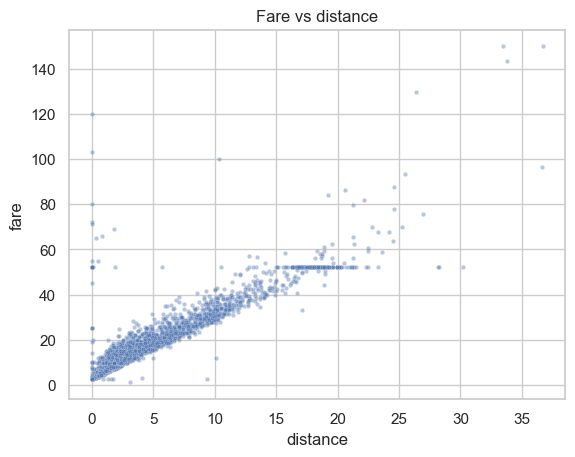

In [24]:
# RUN-TOGETHER
sns.scatterplot(data=taxis, x='distance', y='fare', s=10, alpha=0.4)
plt.title('Fare vs distance')
plt.show()

Let's dive a little deeper

<Axes: xlabel='fare', ylabel='Count'>

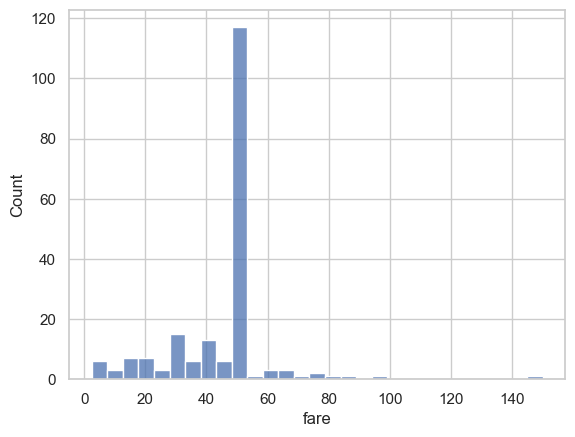

In [25]:
# mask rows with dropoff and pickup at JFK airport
airport_mask = (taxis['dropoff_zone'] == 'JFK Airport') | (taxis['pickup_zone'] == 'JFK Airport')
sns.histplot(data=taxis[airport_mask], x='fare')

In python, the symbol ~ means NOT

So we can use it to graph the data set with all rows that do not NOT match a mask

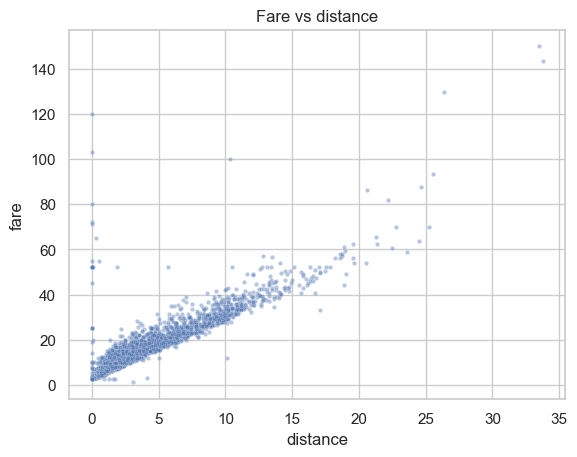

In [26]:
# RUN-TOGETHER
sns.scatterplot(data=taxis[~airport_mask], x='distance', y='fare', s=10, alpha=0.4)
plt.title('Fare vs distance')
plt.show()

What can we say? Fares climb with distance in a tight, roughly linear band. The meter charges by distance (plus time), and the data shows it.

But the exceptions are where EDA requires us to focus. Three features to point at:

- A **horizontal stripe near 52 dollars**, running across many distances. The same fare for wildly different trip lengths: this is our histogram bump from Section 4, now with more evidence. It looks like a *flat rate*. (It is: in 2019, trips between Manhattan and JFK airport were charged a flat fare of 52 dollars. Our dataset contains 131 rides at exactly that fare, and 115 of them start or end at JFK.) **That closes Q8.**
- **Dots pinned to distance 0** with fares well above zero. Zero-mile rides that cost money. That goes in the log as **Q10**.
- A few extreme points in the far upper right: 30-plus-mile, 150-dollar rides.

One plot, three discoveries, and we did not fit a single model.

#### **Activity 7.7 (predict, then run)**

Candidate 2: fuller cabs cost more. It sounds plausible; more people, more service.

**Predict with your neighbor first:** what will the scatterplot of `passengers` vs `fare` look like if the candidate explanation is right? What if it is false? Then fill in the blanks and run.

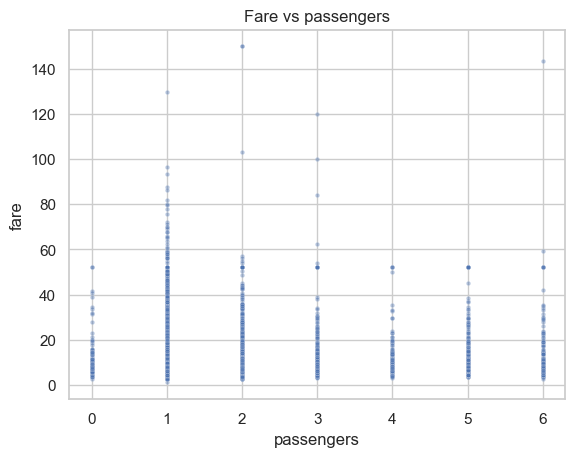

In [27]:
# Activity 7.7
sns.scatterplot(data=taxis, x='passengers', y='fare', s=10, alpha=0.4)
plt.title('Fare vs passengers')
plt.show()

How to read this plot: because `passengers` is a whole number from 0 to 6, the dots line up in seven vertical strips, one per passenger count. 

<Axes: xlabel='passengers', ylabel='fare'>

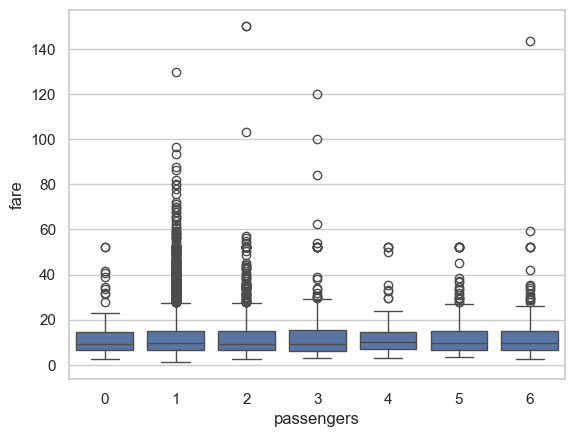

In [28]:
sns.boxplot(data=taxis, x='passengers', y='fare')

The question is whether some strips sit higher than others. They do not: every strip covers about the same range of fares. (If you computed the median fare for each passenger count, every one would land between 9 and 10 dollars.) Notice the strip at 0, too: those are the phantom passengers of Q6.

This is the Activity 7.4 debate paying off. A numerical variable with only a handful of values often reads more clearly when you treat it as categorical, one group per value.

### 5.2 Correlation: one number for a relationship

Our eyes say distance-and-fare is "tight" and passengers-and-fare is "nothing". The **correlation coefficient** r turns that judgment into a number between -1 and 1:

- r near **+1**: as one variable rises, the other reliably rises (tight upward line).
- r near **-1**: as one rises, the other reliably falls.
- r near **0**: no *linear* relationship.

We will treat r intuitively for now (the formula can wait). Three warnings before we compute a single one, because correlation is the most misused number in data science:

1. r sees only **straight-line** patterns. A perfect U-shape can score r = 0.
2. r is **not causation**. Ice cream sales correlate with drownings; summer causes both.
3. r can be dragged around by a few extreme points, and we know our data has some.

In [29]:
# RUN-TOGETHER
print('distance vs fare:      ', taxis['distance'].corr(taxis['fare']).round(2))
print('passengers vs fare:    ', taxis['passengers'].corr(taxis['fare']).round(2))
print('distance vs tip:       ', taxis['distance'].corr(taxis['tip']).round(2))

distance vs fare:       0.92
passengers vs fare:     0.01
distance vs tip:        0.45


The numbers agree with our eyes: 0.92 for distance and fare, 0.01 for passengers and fare, and a middling 0.45 for distance and tip.

To survey all the numeric pairs at once, `.corr()` on a set of columns produces a **correlation matrix**, and a heatmap makes it readable.

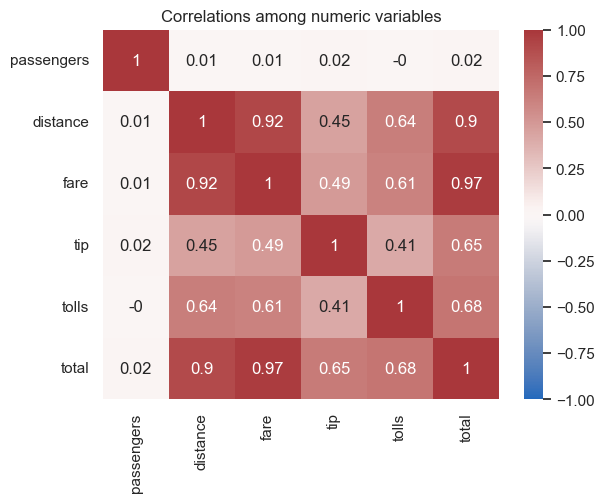

In [30]:
# RUN-TOGETHER
numeric_cols = ['passengers', 'distance', 'fare', 'tip', 'tolls', 'total']
corr_matrix = taxis[numeric_cols].corr().round(2)

sns.heatmap(corr_matrix, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlations among numeric variables')
plt.show()

Reading a correlation matrix is its own small skill:

- The diagonal is all 1s (everything correlates perfectly with itself); ignore it.
- `fare` and `total` correlate at 0.97. Impressive? No: **`total` is computed from `fare`** (fare plus tip, tolls, and surcharges). Correlations that are baked in by arithmetic tell you about bookkeeping, not about the world. Spotting them is part of understanding your columns.
- `passengers` correlates with nothing. An entire row of noise.
- The interesting cluster is distance, fare, and tip, all moderately-to-strongly linked.

#### **Activity 7.8 (Think-Pair-Share)**

A classmate says: "tolls and distance correlate at 0.64, so paying tolls causes trips to be longer." What is wrong with this sentence, and what is the more sensible story?

#### **Class Example 7.1 - The Datasaurus Dozen**

Correlation compresses an entire scatterplot into one number. How much can that compression hide?

In Module 5 you met **Anscombe's Quartet**: four datasets with identical means, standard deviations, and correlation, and four completely different pictures. Here is the same lesson at more than three times the scale.

Below are 13 datasets stacked in one file, each with an `x` column, a `y` column, and a `dataset` label A through M. **All 13 have essentially identical summary statistics**: means and standard deviations that agree to within 0.01, and a correlation between `x` and `y` of about -0.06 or -0.07 in every one. Watch, and predict whether the pictures will match.

In [31]:
# RUN-TOGETHER
# Load the file, relabel the datasets A, B, C, ..., and summarize all 13 at once.
ds_url = ('https://raw.githubusercontent.com/florian-huber/data_science_course/'
          'a595bd6b19565cedff0c3917012be6e05223f7fb/datasets/datasaurus.csv')
saurus = pd.read_csv(ds_url)

new_names = 'ABCDEFGHIJKLM'
convert = {old: new_names[i] for i, old in enumerate(saurus['dataset'].unique())}
saurus['dataset'] = saurus['dataset'].map(convert)

saurus.groupby('dataset')[['x', 'y']].agg(['mean', 'std']).round(2)

x             y       
          mean    std   mean    std
dataset                            
A        54.26  16.77  47.83  26.94
B        54.27  16.77  47.83  26.94
C        54.26  16.77  47.83  26.94
D        54.27  16.77  47.84  26.94
E        54.26  16.77  47.84  26.93
F        54.27  16.77  47.84  26.93
G        54.27  16.77  47.84  26.94
H        54.26  16.77  47.84  26.93
I        54.27  16.76  47.84  26.93
J        54.27  16.77  47.83  26.94
K        54.27  16.77  47.83  26.94
L        54.27  16.77  47.84  26.94
M        54.27  16.77  47.83  26.94

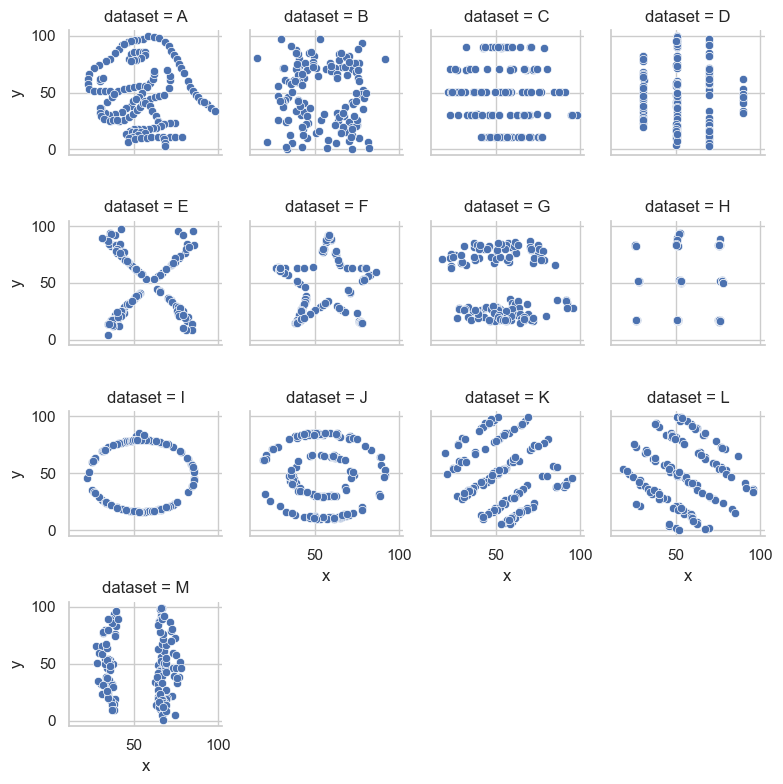

In [32]:
# RUN-TOGETHER
# Predict first: will the scatterplots look alike too?
sns.relplot(data=saurus, x='x', y='y', col='dataset', col_wrap=4, height=2)
plt.show()

A dinosaur. A star. Concentric circles. Parallel stripes. Thirteen wildly different pictures with identical statistical summaries.

The moral is the one Module 5 opened with: **summary statistics compress, and compression destroys information. Always, always plot your data.** (This collection is the "Datasaurus Dozen" of Matejka and Fitzmaurice, 2017, a modern descendant of Anscombe's quartet from 1973.)

Connect it back to our taxis: which of our discoveries would summary statistics alone have missed? The clearest case is the 52-dollar stripe: no mean, median, or correlation hints at it. The zero-tip spike is a partial case: `describe()` showed a 25th percentile of 0, but only the histogram made the spike impossible to ignore. The plots did the finding; the statistics confirmed the details.

### 5.3 A categorical and a numerical variable: group summaries

Candidate 3 asked whether boroughs differ. The tool is `groupby()` from Module 6: split the rides by borough, then summarize a numeric column within each group.

In [33]:
# RUN-TOGETHER
taxis.groupby('pickup_borough')[['distance', 'fare', 'duration_min']].mean().round(2)

,distance,fare,duration_min
pickup_borough,,,
Bronx,5.73,21.00,24.50
Brooklyn,4.06,16.52,18.93
Manhattan,2.35,11.15,12.79
Queens,7.47,24.93,22.89


Let's investigate futher 

<Axes: xlabel='distance', ylabel='Count'>

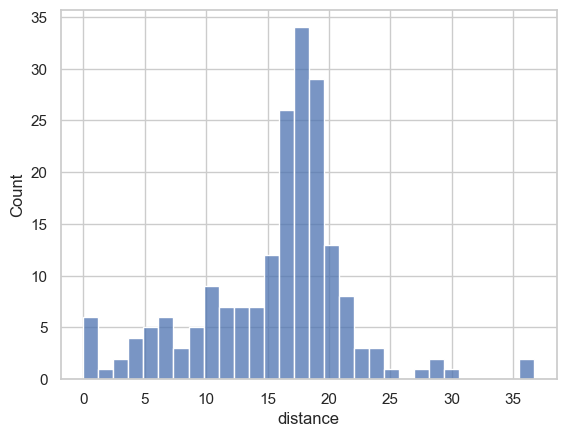

In [34]:
sns.histplot(data=taxis[airport_mask], x='distance', bins=30)

Now the borough differences have numbers: Queens pickups average 7.5 miles and about 25 dollars, against Manhattan's 2.3 miles and 11 dollars. That is more than three times the distance and a bit more than twice the fare. Before reaching for exotic explanations, look at a map: **both major airports sit in Queens**. Airport runs are long, and they dominate that borough's average.

One caution that applies to every group summary: check the group *sizes*. The Bronx mean rests on only 99 rides; Manhattan's on 5,268. Small groups make jumpy averages.

### 5.4 Comparing distributions across groups

Group *means* compress each group to one number. To see whether the borough differences are about whole distributions and not just averages, the boxplot becomes a team sport: one box per group, sharing an axis.

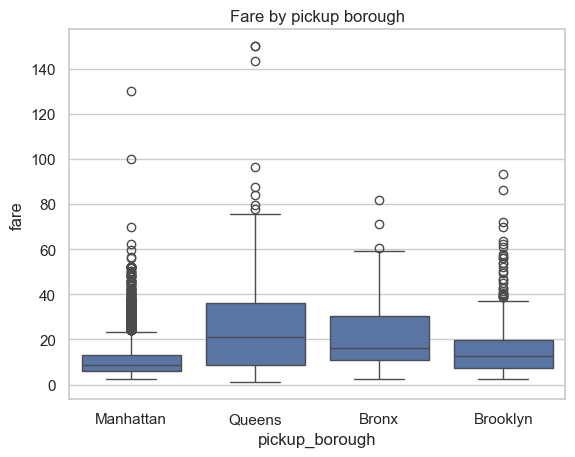

In [35]:
# RUN-TOGETHER
sns.boxplot(data=taxis, x='pickup_borough', y='fare')
plt.title('Fare by pickup borough')
plt.show()

The Queens box floats higher and stretches wider, telling us its fares are not just bigger on average but more variable (a mix of local trips and airport runs). Manhattan's box is low and tight with a long fringe of flagged points. One picture, four distributions, directly comparable.

### 5.5 Following up Q9: who rides at 4 am?

Back in Section 4.4 the hourly counts raised Q9: are the few pre-dawn rides *different in kind*? We now have the tool to check: group the rides by `pickup_hour` and summarize `distance` within each hour.

**Predict first:** if pre-dawn rides are different, what would the mean distance for hours 4 and 5 look like compared with the rest of the day?

In [36]:
# RUN-TOGETHER
# Mean trip distance for each pickup hour (0 = midnight to 1 am, ..., 23 = 11 pm to midnight)
taxis.groupby('pickup_hour')['distance'].mean().round(2)

pickup_hour
0     3.63
1     3.20
2     3.24
3     3.45
4     4.42
5     5.13
6     3.32
7     3.32
8     2.63
9     2.71
10    2.76
11    2.66
12    3.14
13    2.80
14    3.08
15    3.23
16    3.29
17    3.06
18    2.77
19    2.74
20    2.86
21    3.20
22    2.95
23    3.12
Name: distance, dtype: float64

Hours 4 and 5 stand out: mean distances of 4.42 and 5.13 miles, against 3.02 miles for all rides. Pre-dawn rides are roughly one and a half times as long as a typical ride.

The answer immediately creates the next question: *why?* Section 5.3 handed us a candidate. Airport trips are long, and early flights mean early taxis. If airports explain the pattern, then (a) airport trips should make up a bigger share of pre-dawn rides, and (b) once we set airport trips aside, pre-dawn rides should look ordinary.

Two new tools in the next cell:
- `.str.contains('Airport', na=False)` checks whether each zone name contains the word "Airport" (`na=False` treats a missing zone as "no").
- `~` flips a True/False mask, so `~airport` means "not an airport trip".

In [37]:
# RUN-TOGETHER
# True when the ride starts OR ends in a zone whose name contains "Airport"
airport = (taxis['pickup_zone'].str.contains('Airport', na=False) |
           taxis['dropoff_zone'].str.contains('Airport', na=False))
early = taxis['pickup_hour'].isin([4, 5])     # True for pickups from 4:00 to 5:59 am

print('airport share, all rides:      ', airport.mean().round(3))
print('airport share, 4 to 5 am rides:', airport[early].mean().round(3))
print()
print('mean distance, non-airport rides, all hours:', taxis[~airport]['distance'].mean().round(2))
print('mean distance, non-airport rides, 4 to 5 am:', taxis[early & ~airport]['distance'].mean().round(2))

airport share, all rides:       0.063
airport share, 4 to 5 am rides: 0.139

mean distance, non-airport rides, all hours: 2.39
mean distance, non-airport rides, 4 to 5 am: 3.11


Prediction (a) holds: airport trips are about 14% of pre-dawn rides but only about 6% of all rides, more than twice as common. Prediction (b) does not: even with airport trips set aside, pre-dawn rides average 3.11 miles, against 2.39 for non-airport rides overall.

So airports are **part** of the story, not all of it. **Q9 is partly closed**, and the loop has handed us **Q11**: what else makes pre-dawn rides long? We do not know. Possible stories include fewer short hops between nearby neighborhoods at that hour, or empty streets making long trips fast enough to be worth a cab, but those are guesses, and this dataset cannot easily check them.

That is a normal and honest place for an EDA thread to stop: one part explained, one part written down as an open question.

### 5.6 Following up Q3: the tipping mystery

Time to cash in Q3. Activity 7.6 showed that at least a quarter of all tips are exactly zero. Are New Yorkers really that cold?

Maybe it depends on **how people pay**. That is a categorical-numerical question, so it is a job for `groupby()`.

In [38]:
taxis.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough', 'duration_min', 'pickup_hour',
       'pickup_day'],
      dtype='str')

<Axes: xlabel='tip', ylabel='Count'>

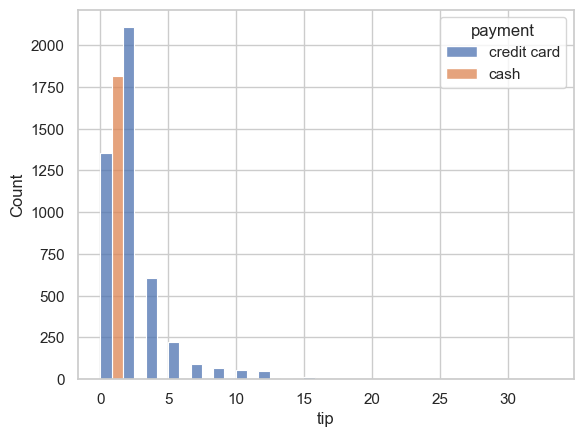

In [39]:
# FILL-IN TOGETHER
sns.histplot(data=taxis, x='tip', hue = 'payment', multiple = 'dodge', bins = 20)

In [40]:
# RUN-TOGETHER
tip_mask = taxis['tip'] == 0
print('share of rides with a tip of exactly 0:', tip_mask.mean().round(3))
print()
print(taxis.groupby('payment')['tip'].mean().round(2))
print()
print('zero-tip rides by payment type:')
print(taxis[tip_mask]['payment'].value_counts())

share of rides with a tip of exactly 0: 0.359

payment
cash           0.00
credit card    2.78
Name: tip, dtype: float64

zero-tip rides by payment type:
payment
cash           1812
credit card     455
Name: count, dtype: int64


First the share: 36% of all rides record a tip of exactly zero. Now the group means: the mean tip on cash rides is not merely small. It is **0.00. Every single one of the 1,812 cash rides records a tip of exactly zero.**

Real populations do not behave like that; 1,812 people do not unanimously tip nothing. When a value is *impossibly* consistent, we do not blame the people. Instead we investigate the measurement.
>The actual explanation: the taxi meter only records tips paid by card.

Cash tips happen, in the back seat, off the books; the dataset simply never sees them. (The TLC documents this limitation of its trip records.)

Pause on what just happened:

- The value 0 is not "missing". It is not flagged. It passes every format check. The data is, in a bookkeeping sense, perfectly clean, **and it still lies**.
- A model trained naively on this data would learn that cash customers never tip, and someone might make a policy decision downstream of that artifact.
- No algorithm catches this. It was caught by a person who looked at a suspicious spike, asked why, split the data by a category, and knew a little about how taxi meters work.

**Q3 is closed**, and the answer rewrites Q1: every tip number in this dataset describes card-paying riders only.

That is exploratory data analysis.

### 5.7 Two categorical variables: crosstabs

A colleague runs one line of code and gets excited:

In [41]:
# RUN-TOGETHER
taxis.groupby('color')['tip'].mean().round(2)

color
green     0.80
yellow    2.19
Name: tip, dtype: float64

Recorded tips average 2.19 dollars in yellow cabs and only 0.80 in green cabs. The colleague drafts a headline: **"Green cab riders tip far less."**

After 5.6 you should be suspicious. Cash tips are recorded as 0, so if green-cab riders pay cash more often, their recorded tips will look lower even if their real tips are not. That opens **Q12**: *do green and yellow riders pay differently?*

Color and payment are both categorical, and the tool for a pair of categorical variables is the **cross-tabulation**: a grid of counts for every combination of two categories.

In [42]:
# RUN-TOGETHER
print(pd.crosstab(taxis['color'], taxis['payment']))
print()
# normalize='index' turns each ROW into proportions that sum to 1
print(pd.crosstab(taxis['color'], taxis['payment'], normalize='index').round(2))

payment  cash  credit card
color                     
green     400          577
yellow   1412         4000

payment  cash  credit card
color                     
green    0.41         0.59
yellow   0.26         0.74


The raw counts are hard to compare because there are five times as many yellow rides, which is exactly why the normalized version exists: within green cabs, 41% of rides are cash; within yellow cabs, 26%. Green-cab riders do pay cash more often, so the colleague is partly comparing payment habits, not generosity. A crosstab is just `value_counts()` grown up to two dimensions, and `normalize` chooses which direction we compare in.

#### **Activity 7.9**

Is the headline "Green cab riders tip far less" justified, or is the gap entirely a payment-mix artifact?

a. Compare recorded tips by color **among card-paid rides only**, where tips are actually recorded. Fill in the blanks below.

b. Write two sentences to your colleague. What does the payment mix explain, and what (if anything) does it leave unexplained?

In [43]:
# Activity 7.9
# a. keep only the card-paid rides, then compare mean tip by color
card = taxis[taxis['payment'] == 'credit card']
card.groupby('color')['tip'].mean().round(2)

# b. your two sentences, as a comment:
#

color
green     1.35
yellow    2.99
Name: tip, dtype: float64

#### Question log update (end of Section 5)

- **Closed Q8.** The 52-dollar bump is the Manhattan-JFK flat fare (5.1).
- **Q9 partly closed.** Pre-dawn rides are longer, and airport trips are part of the reason (5.5).
- **Closed Q3.** Cash tips are recorded as 0 (5.6). This changes Q1: tip data describes card-paying riders only.
- **Q12 answered.** Green-cab riders pay cash more often, which exaggerates the green-yellow gap in recorded tips (5.7). Activity 7.9 asks whether it explains the whole gap.
- **Opened Q10:** zero-mile rides that still cost money (5.1).
- **Opened Q11:** what besides airport trips makes pre-dawn rides long? (5.5)

---
## 6. Detecting Data Quality Problems
---

All module long, oddities have been piling up in our Question log, and the ones still open are mostly about data quality:
- Q4: 44 missing payments and dozens of missing zones,
- Q5: a 150-dollar maximum fare, real or error?
- Q6: rides with zero passengers,
- Q10: zero-mile rides that still cost money.

A working EDA quality sweep has four checks: **missing values, duplicates, impossible values, and outliers.** We begin by talking about ways to *detect and document*. Deciding what to do about each problem (delete? fill in? keep?) is the subject of the next module on data cleaning, and good decisions there depend entirely on the careful detective work here.

### 6.1 Missing values

`info()` hinted at missing data back in Section 2. The direct tool is `isna()`, which returns True/False for every cell, and column sums turn those into counts.

In [44]:
# RUN-TOGETHER
print(taxis.isna().sum())
print()
print('rows with at least one missing value:', taxis.isna().any(axis=1).sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
duration_min        0
pickup_hour         0
pickup_day          0
dtype: int64

rows with at least one missing value: 92


Missingness is confined to `payment` (44) and the four location columns (26 to 45 each), touching 92 rows in all, about 1.4% of the data. Nothing is missing in the money or distance columns.

Counting is not understanding, though. Before deciding anything, **look at the actual afflicted rows**: do they seem otherwise normal, or is missingness a symptom of a deeper problem?

In [45]:
# RUN-TOGETHER
taxis[taxis['payment'].isna()].head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,duration_min,pickup_hour,pickup_day
7,2019-03-22 12:47:13,2019-03-22 12:58:17,0,1.4,8.5,0.0,0.0,11.8,yellow,NaN,Murray Hill,Flatiron,Manhattan,Manhattan,11.066667,12,Friday
445,2019-03-19 06:57:14,2019-03-19 07:00:08,1,1.3,5.5,0.0,0.0,6.3,yellow,NaN,Boerum Hill,Columbia Street,Brooklyn,Brooklyn,2.900000,6,Tuesday
491,2019-03-07 07:11:33,2019-03-07 07:11:39,1,1.6,2.5,0.0,0.0,5.8,yellow,NaN,Murray Hill,Murray Hill,Manhattan,Manhattan,0.100000,7,Thursday
545,2019-03-27 11:03:43,2019-03-27 11:14:34,1,4.2,15.0,0.0,0.0,15.8,yellow,NaN,LaGuardia Airport,Forest Hills,Queens,Queens,10.850000,11,Wednesday
621,2019-03-15 17:16:35,2019-03-15 17:25:01,1,1.3,7.5,0.0,0.0,11.8,yellow,NaN,Upper East Side North,Upper East Side South,Manhattan,Manhattan,8.433333,17,Friday


These rows look like ordinary rides that simply lack a payment entry, with one curiosity: look at the `tip` column, which is 0 in every row shown. A coincidence, or a clue? (Given Q3, these could be cash rides, but nothing in the data confirms it.)

The question that actually matters is: **is the missingness random, or systematic?** If the missing values pile up in one kind of ride, dropping those rows would quietly bias every conclusion downstream. With 44 rows and few clues, the payment question is hard to settle. The missing `dropoff_zone` values are a different story, because we can compare those rides with everyone else.

In [46]:
# RUN-TOGETHER
# Group the rides by whether dropoff_zone is missing (True) or recorded (False),
# then compare the two groups.
missing_dropoff = taxis['dropoff_zone'].isna()
taxis.groupby(missing_dropoff)[['distance', 'fare']].describe().round(2)

distance                                               fare  \
                count  mean    std  min   25%   50%   75%    max   count   
dropoff_zone                                                               
False          6388.0  3.00   3.72  0.0  0.99  1.64   3.2  36.70  6388.0   
True             45.0  7.17  10.71  0.0  0.00  0.90  12.6  36.66    45.0   

                                                         
               mean    std  min  25%   50%   75%    max  
dropoff_zone                                             
False         12.87  10.73  1.0  6.5   9.5  15.0  150.0  
True          43.84  42.74  2.5  9.0  25.0  78.0  150.0

Read the `True` row as "rides missing a dropoff zone". Those 45 rides average about 7.2 miles and 44 dollars, against 3.0 miles and 13 dollars for everyone else. That is not random. Whatever causes a missing dropoff zone, it happens mostly on long, expensive trips, so dropping these rows would remove a slice of the most expensive rides, not a random handful.

One plausible explanation, which we have **not** verified: trips that end outside New York City may not be assigned one of the city's zone names. Checking it would mean reading the TLC's zone documentation, which is exactly the kind of outside knowledge EDA often sends you to look up.

In the next module on cleaning we will discuss deletion strategies and imputation, with their trade-offs.

#### **Activity 7.10 (Think-Pair-Share)**

Which is the more damaging hole in this dataset: the **44 missing `payment`** values, or the **45 missing `dropoff_zone`** values?

Argue it both ways before you settle, and use the comparison above. (Hint: damaging *for which analysis?* Think about a fare model, and about Q1.)

### 6.2 Duplicates

Large data pipelines (especially across multiple sources or collaborators) can create duplicate rows.  A file gets submitted twice, a merge goes sideways, a sensor hiccups.

In [47]:
# RUN-TOGETHER
print('duplicated rows in taxis:', taxis.duplicated().sum())

# A tiny demonstration of what duplicated() catches:
demo = pd.DataFrame({'ride': [1, 2, 2, 3], 'fare': [7.0, 9.5, 9.5, 12.0]})
print()
print(demo)
print()
print(demo.duplicated())          # True marks the SECOND appearance
print()
print(demo.drop_duplicates())     # one line to remove them

duplicated rows in taxis: 0

   ride  fare
0     1   7.0
1     2   9.5
2     2   9.5
3     3  12.0

0    False
1    False
2     True
3    False
dtype: bool

   ride  fare
0     1   7.0
1     2   9.5
3     3  12.0


Our taxi sample comes back clean: zero exact duplicates. Two footnotes worth saying aloud:

- `duplicated()` flags rows where **every** column matches. Two different rides that coincidentally share a fare are not duplicates; two rows agreeing on all 14 fields, including pickup time to the second, almost certainly are.
- A clean result is still a result. "I checked for duplicates and found none" belongs in your findings.

### 6.3 Impossible and suspicious values

Missing data announces itself. The more dangerous problems are values that are *present, well-formatted, and impossible*. No function called `find_impossible_values()` exists, because impossibility depends on what the data means. What we have instead are **boolean masks** (Module 6) plus common sense about taxis.

Two red flags are already in our log:
- rides with no passengers (Q6),
- rides with no distance but a fare (Q10).

Let us count those, and add one check we have not made yet: now that we have `duration_min`, are there rides that took no time at all, or less than none?

In [48]:
# RUN-TOGETHER
print('rides with 0 passengers:            ', (taxis['passengers'] == 0).sum())
print('0-distance rides that cost money:   ',
      ((taxis['distance'] == 0) & (taxis['fare'] > 0)).sum())
print('rides with non-positive duration:   ', (taxis['duration_min'] <= 0).sum())

rides with 0 passengers:             96
0-distance rides that cost money:    51
rides with non-positive duration:    6


In [49]:
# RUN-TOGETHER
# Look at the worst offenders: zero-distance rides, most expensive first.
zero_dist = taxis[taxis['distance'] == 0]
zero_dist.sort_values('fare', ascending=False)[
    ['pickup', 'distance', 'duration_min', 'fare', 'total', 'pickup_zone', 'dropoff_zone']
].head()

,pickup,distance,duration_min,fare,total,pickup_zone,dropoff_zone
622,2019-03-12 19:52:36,0.0,0.316667,120.0,166.00,NaN,NaN
3644,2019-03-19 23:30:50,0.0,1.716667,103.0,123.95,NaN,NaN
42,2019-03-30 23:59:14,0.0,0.050000,80.0,100.38,NaN,NaN
1690,2019-03-22 06:24:14,0.0,0.000000,72.0,72.00,East New York,NaN
6393,2019-03-10 18:33:13,0.0,59.416667,71.2,72.00,Parkchester,Flatbush/Ditmas Park


In [50]:
# RUN-TOGETHER
# The rides with non-positive duration, in full
taxis[taxis['duration_min'] <= 0][['pickup', 'dropoff', 'distance', 'fare']]

,pickup,dropoff,distance,fare
1690,2019-03-22 06:24:14,2019-03-22 06:24:14,0.0,72.0
5493,2019-03-06 12:14:00,2019-03-06 12:14:00,0.0,10.0
5624,2019-03-11 14:04:50,2019-03-11 14:04:50,0.0,2.5
5638,2019-03-13 12:22:00,2019-03-13 12:22:00,0.0,10.0
6083,2019-03-19 15:34:00,2019-03-19 15:34:00,0.0,5.0
6356,2019-03-01 16:58:23,2019-03-01 16:58:23,0.0,3.0


The tally: 96 phantom-passenger rides, 51 zero-mile rides with fares reaching 120 dollars, and 6 rides with non-positive duration. Look closely at those 6: none is negative. In every one the pickup and dropoff times are identical to the second, and every one also has a distance of 0. They may be the same kind of problem as the zero-mile rides, seen through a different column.

What *are* these? We do not know, and it is important to be comfortable saying so. Plausible stories include a driver forgetting to enter the passenger count, a meter started and cancelled but still charged, a GPS failure recording no distance, or clock errors. The data cannot tell us which.

What do we do about these rows of data? Not a fix but a *documented inventory*: which rows, how many, and the plausible explanations. Whether to drop, repair, or keep them is a cleaning decision, and the right choice will depend on our analysis. For a fare model, a 120-dollar zero-mile ride may be toxic to the model and analysis.

#### **Activity 7.11**

Investigate the luxury end: rides with a **fare above 100 dollars**.

a. How many are there?

b. Display their `distance`, `fare`, `pickup_zone`, and `dropoff_zone`.

c. In a comment: which of these look like real (if pricey) rides, and which look like data problems? What tips you off? (Look at the `dropoff_zone` column with Section 6.1 in mind.)

In [51]:
# Activity 7.11
expensive = taxis[taxis['fare'] > 100]

# a. how many?
print('rides over $100:', expensive.shape[0])

# b. inspect the relevant columns
expensive[['passengers', 'tip', 'pickup_zone', 'dropoff_zone']]

# c. your verdict as a comment:
#

rides over $100: 6


,passengers,tip,pickup_zone,dropoff_zone
622,3,33.20,NaN,NaN
2231,1,0.00,East Harlem North,NaN
3644,2,20.65,NaN,NaN
4050,6,0.00,LaGuardia Airport,NaN
5364,2,0.00,JFK Airport,JFK Airport
5648,2,0.00,East Flushing,NaN


### 6.4 Outliers: an introduction

The zero-distance rides were *impossible*. But what about the handful of 33- to 37-mile rides that cost 140 to 150 dollars? Nothing about them is impossible; they are just far from everything else. Values like this are called **outliers**: observations distant from the bulk of the data.

Flagged outlier points come in at least three kinds, with three different fates:

1. **Errors** (the 120-dollar zero-mile ride): fix or remove, during cleaning.
2. **True but rare values** (a genuine 30-mile trip to the edge of the city or beyond): keep; deleting them fabricates a tidier world than the one you live in.
3. **A hidden subpopulation** (the 52-dollar flat-rate stripe): a real group that deserves its own look, not deletion.

A common flagging heuristic is the rule from Section 4. Compute the quartiles and the interquartile range, then flag anything outside the fences:

- lower fence = Q1 - 1.5 × IQR
- upper fence = Q3 + 1.5 × IQR

In [52]:
# RUN-TOGETHER
q1 = taxis['fare'].quantile(0.25)
q3 = taxis['fare'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print('fences:', round(lower, 2), 'to', round(upper, 2))

flagged_mask = (taxis['fare'] < lower) | (taxis['fare'] > upper)
flagged = taxis[flagged_mask]
print('flagged rides:', flagged.shape[0],
      '=', round(100 * flagged.shape[0] / taxis.shape[0], 1), '% of the data')

# airport is the True/False mask we built in Section 5.5
print('airport rides flagged:', (flagged_mask & airport).sum(), 'of', airport.sum())

fences: -6.25 to 27.75
flagged rides: 592 = 9.2 % of the data
airport rides flagged: 314 of 407


The rule flags 592 rides, nine percent of the dataset, as "outliers", including 314 of the 407 rides that start or end at an airport. (The lower fence is negative, so nothing is flagged on the cheap side; on right-skewed data this is common.)

Nine percent of a dataset is not a fringe; it is a constituency. If we mechanically deleted the flagged rows, we would erase airport travel from our picture of NYC taxis and then wonder why our fare model fails every traveler with a suitcase. So the workflow is: the rule *flags*, a human *investigates*, and any removal happens later, deliberately, with reasons written down.

#### **Activity 7.12**

Run the same IQR analysis on **`distance`**:

a. Compute the fences and the number of flagged rides.

b. Display the 5 longest rides with their zones.

c. In a comment: are the longest rides errors or real? What in the other columns supports your call? Look closely at the very longest ride's pickup and dropoff zones: what would you want to know before calling it real?

In [53]:
# Activity 7.12
q1 = taxis['distance'].quantile(0.25)
q3 = taxis['distance'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print('upper fence:', round(upper, 2), 'miles')
print('flagged:', (taxis['distance'] > upper).sum())

# b. the 5 longest rides
taxis.sort_values('distance', ascending=False)[
    ['distance', 'fare', 'pickup_zone', 'dropoff_zone']
].head()

# c. your verdict:
#

upper fence: 6.56 miles
flagged: 734


,distance,fare,pickup_zone,dropoff_zone
5364,36.70,150.0,JFK Airport,JFK Airport
4219,36.66,96.5,JFK Airport,NaN
4050,33.76,143.5,LaGuardia Airport,NaN
5648,33.46,150.0,East Flushing,NaN
2397,30.23,52.0,JFK Airport,Meatpacking/West Village West


#### Question log update (end of Section 6)

- **Q4 closed, with a split verdict.** The 44 missing payments look like ordinary rides, and we cannot tell whether they are random. The 45 missing dropoff zones are clearly systematic: they are concentrated in long, expensive trips (6.1).
- **Q5 closed.** The 150-dollar maximum belongs to trips of 33 and 37 miles, so it is plausible. The rest of the 100-dollar club is more mixed (Activity 7.11).
- **Q6 and Q10 documented, not explained.** 96 zero-passenger rides, 51 zero-mile rides with fares, and 6 zero-duration rides (all of them also zero-mile). The data cannot tell us why; the cleaning module will decide what to do with them.

---
## 7. EDA as an Iterative Process
---

In Section 1 we promised a loop. Here is what it looked like in practice, read straight off our Question log:

- *What do fares look like?* -> histogram -> **a bump at 52 dollars** (Q8) -> *why?* -> scatterplot -> a flat-rate stripe -> the JFK flat fare.
- *Some tips are 0* (Q3) -> histogram -> **at least a quarter of tips are exactly 0** -> *who tips zero?* -> group by payment -> **cash tips are never recorded** -> which rewrote the boss's question (Q1) and raised a new one about green cabs (Q12).
- *When do people ride?* -> counts by hour -> **a 4-to-5 am trickle** (Q9) -> *are those rides different?* -> mean distance by hour -> **pre-dawn rides are about 1.5 times as long** -> *airports?* -> **partly** -> a new open question (Q11).
- *What period does the data cover?* -> min and max of `pickup` -> **one month** -> Q1 cannot be answered as asked.

Nobody could have written those questions down in advance, because each one was *created by the previous answer*. That is why EDA cannot be fully automated, and why it rewards curiosity more than memorized commands.

#### The complete Question log

| # | Question | Raised in | Where it went |
| --- | --- | --- | --- |
| Q1 | Are riders tipping less than they used to? | Activity 7.1 | Cannot be answered with this data (see the memo below) |
| Q2 | Are `pickup` and `dropoff` usable as times? | 2 | Closed in 3.3: repaired with `pd.to_datetime()` |
| Q3 | Why are so many tips exactly 0? | 2, Activity 7.6 | Closed in 5.6: cash tips are not recorded |
| Q4 | Is the missingness random? | 2 | Closed in 6.1: payment unclear; dropoff zones systematic |
| Q5 | Is there a long tail? Is 150 dollars real? | 2 | Closed in 4.2 (right skew) and 6.4 (plausible long trips) |
| Q6 | Rides with 0 passengers? | 2 | Documented in 6.3; cause unknown |
| Q7 | Why 5 dropoff boroughs but 4 pickup boroughs? | 2 | Closed in Activity 7.3(d) |
| Q8 | Why a fare bump near 52 dollars? | 4.2 | Closed in 5.1: Manhattan-JFK flat fare |
| Q9 | Are 4 to 5 am rides different? | 4.4 | Partly closed in 5.5: longer, partly because of airport trips |
| Q10 | Zero-mile rides that cost money? | 5.1 | Documented in 6.3; cause unknown |
| Q11 | What else makes pre-dawn rides long? | 5.5 | **Still open** |
| Q12 | Do green and yellow riders pay differently? | 5.7 | Closed in 5.7: yes; Activity 7.9 asks whether that explains the tip gap |

One question is still open and another is only partly answered, and that is normal. An EDA that closes every question probably did not ask enough of them.

### 7.1 What we now know: a findings memo

Every EDA session should end with written findings, because understanding that stays in your head can evaporate in a week. Ours starts where the module started, with the boss's question.

**Answer to Q1 ("Are riders tipping less than they used to?").** This dataset cannot answer it, for two independent reasons. First, it covers a single month, so there is nothing to compare against. Second, cash tips are recorded as 0, so tip data describes only card-paying riders (about 72% of rides with a recorded payment). To answer Q1 we would need TLC records from several years, analyzed for card-paid rides only, with a clear statement that cash tipping is invisible. That is still a useful answer: it tells the boss what data to request, and what any future answer will and will not cover.

**Other findings:**

1. The dataset covers 6,433 NYC taxi rides from March 2019 (plus one ride that began late on February 28); one row per ride; the file is sorted by cab color; heavily weighted toward Manhattan pickups (82%) and yellow cabs (85%).
2. Fares, distances, tips, and durations are all right-skewed; medians (9.50 dollars, 1.6 miles, 11 minutes) describe a typical ride far better than means.
3. Fare rises almost linearly with distance (r = 0.92); the number of passengers is irrelevant to price (r = 0.01).
4. A cluster of 131 rides at exactly 52 dollars reflects the Manhattan-JFK flat fare, not an anomaly.
5. Cash tips are structurally recorded as zero, so every tip statistic describes card-paying riders only. Cross-group tip comparisons (like yellow versus green) are distorted by payment mix, although in this sample green-cab tips are lower even among card payers.
6. Queens pickups are longest and priciest (airports). Pre-dawn rides average about 1.5 times the typical distance; airport trips explain part of that, but not all.
7. Quality inventory: 92 rows (1.4%) have missing payment or location fields, and the missing dropoff zones are concentrated in long, expensive trips; 0 duplicate rows; 96 zero-passenger rides; 51 zero-distance rides with positive fares; 6 zero-duration rides (all also zero-distance).
8. The 1.5 × IQR rule flags about 9 to 11% of rides on fare and distance, nearly all of them legitimate long trips, including most airport trips; deletion by rule would erase much of airport travel.

Notice how many of these would change how we would build a fare model.

### 7.2 The hand-off: from exploring to cleaning and modeling

EDA does not end an analysis; it *sets the agenda* for the next stages.

**For the cleaning module (next),** our findings convert directly into a to-do list of decisions: what to do with 44 missing payments (drop? impute? keep as a category?), whether zero-distance and zero-passenger rides are salvageable or must go, what to do with the 6 zero-duration rides, whether rides with a missing dropoff zone can be dropped without removing a slice of expensive trips, and whether flat-rate JFK rides should be treated as their own category. Every one of those is a judgment call.

**For modeling (later),** EDA has already scouted the terrain:
- distance will carry a fare model almost by itself;
- hour and borough may add additional information; passengers adds nothing; and
- any model of tips must first reckon with "cash tips are structurally recorded as zero" or it will not be a good model.

```
ASK  ->  GET  ->  EXPLORE  ->  MODEL  ->  COMMUNICATE
 ^                                            |
 |________ findings raise new questions ______|
```

The pipeline diagram runs left to right, but the arrows secretly point both ways. You will come back and explore again after cleaning, and again after the first bad model. Every return trip is faster, because now you know the data.

### 7.3 A first-hour checklist for any new dataset

The EDA loop cannot be scripted, but the opening moves can.

1. Load the data and look at `head()`, `tail()`, and a random `sample()`.
2. Check `shape`: how much data do you actually have?
3. Read `info()`: missing values? wrong dtypes?
4. Read `describe()` for numeric columns and `describe(exclude='number')` for the rest; circle anything odd.
5. Classify each variable: numerical, categorical, datetime. Repair mis-typed columns and derive the ones you need.
6. For each key variable alone: `value_counts()` and bar charts (categorical); histogram, boxplot, and summary statistics (numerical). Try more than one bin width.
7. For key pairs: scatterplots, correlations, group summaries, crosstabs.
8. Hunt for trouble: missing values, duplicates, impossible values, extreme values.
9. Keep a question log: write down findings **and** open questions as you go, not at the end.
10. Only then start deciding what to clean and what to model.

---
## 8. Practice Problem (take-home)
---

#### **Practice Problem 7.1 - Green cabs versus yellow cabs**

*This one is yours to do outside of class.*

Your first real assignment from the TLC: *"We want to know whether green cabs serve different kinds of trips than yellow cabs."*

That is a real, open-ended question, exactly as vague as they come on the job. Work through the parts below; the blanks get sparser as you go, until the last part is all yours.

In [ ]:
# Practice Problem 7.1, Part A: isolate and size up the green rides
green = taxis[taxis['color'] == ____]

print('green rides:', green.shape[0], 'of', taxis.shape[0])
print('as a share:', round(green.shape[0] / taxis.shape[0], 3))

In [ ]:
# Practice Problem 7.1, Part B: where do green cabs pick up, compared to yellow?
# (Section 4 tools: value_counts with normalize, one per color)
print('GREEN pickups by borough:')
print(green['pickup_borough'].value_counts(normalize=True).round(2))
print()
print('YELLOW pickups by borough:')
yellow = taxis[taxis['color'] == ____]
print(yellow[____].value_counts(normalize=True).round(2))

In [ ]:
# Practice Problem 7.1, Part C: do trip characteristics differ?
# Compare distance, fare, and duration across the two colors in ONE table.
taxis.groupby(____)[['distance', 'fare', 'duration_min']].____().round(2)

In [ ]:
# Practice Problem 7.1, Part D: compare the DISTRIBUTIONS of distance, not just the means.
# One boxplot per color, sharing an axis (Section 5.4).
sns.boxplot(data=taxis, x=____, y=____)
plt.title('Trip distance by cab color')
plt.show()

In [ ]:
# Practice Problem 7.1, Part E: quality check within the green subset, YOUR way.
# At minimum: missing values per column, and how many zero-distance rides.
# (No blanks here. You have all the tools.)

**Part F.** In a new markdown cell, write your memo to the TLC:

- **three findings**, each one sentence, each backed by a number or plot from Parts A through E;
- **one caution** about a comparison this data cannot fairly make (Section 5 gave you a big one);
- **one next question** you would investigate with more time or more data.

This structure (findings, cautions, next questions) is the report format of working data scientists. Sentence quality counts; you are writing for a boss, not a grader.

---
## Adding to the Toolkit
---

Every module from here to the final adds rows to one running table. By the last week you will have the whole collection, and the review will be about **choosing** from it: given the feature types you have and the question you were asked, which tool is right?

The columns never change:

| Tool | Question it answers | Feature types it needs | Label needed? | Key assumption | How it fails |
| --- | --- | --- | --- | --- | --- |
| **`describe()` / five-number summary** | What is the range and center of each numeric column? | interval or ratio | no | the summary is not hiding structure | Anscombe and the Datasaurus: identical summaries, different data |
| **Correlation $r$** | How strongly do two numeric variables move together, in a straight line? | two interval or ratio | no | the relationship is **linear** | blind to curves; a single outlier can move it; never implies causation |
| **`groupby` summary** | Does a numeric variable differ across groups? | one numeric, split by one categorical | no | the groups are meaningful and large enough | small groups give jumpy averages; check the counts |
| **Crosstab** | Are two categorical variables associated? | two nominal or ordinal | no | the cells have enough counts | raw counts mislead when group sizes differ; use `normalize` |
| **1.5 x IQR fence** | Which values sit unusually far from the middle? | one interval or ratio | no | the distribution is roughly symmetric | on skewed data it flags the long tail: 9% of taxi fares, mostly legitimate long and airport trips |

**The trap this table is built around.** Every row in it compresses. Anscombe's Quartet and the Datasaurus exist to prove that compression destroys information, which is why no row here is ever a substitute for the plots in Module 5. For a complete and honest story we need the summary *and* a picture, every time.

## Suggested Exercises

1. A hospital hands you a table with one row per emergency-department visit and the columns `patient_id`, `admit_time`, `department`, `room_number`, `age`, `triage_level` (1 through 5), and `stay_hours`.

    a. Classify each column as numerical, categorical, or datetime.

    b. Two columns are stored as integers but are not numerical. Name them, and say what goes wrong if you average each one.

    c. `triage_level` is stored as an integer and genuinely *is* ordered. Which measurement scale from Module 2 is it, and is the mean or the median the defensible summary?

    d. Name one column you would derive from `admit_time`, and one question that derived column would let you answer.

2. You are given a numeric column and told its mean is 48 and its median is 31.

    a. Predict the skew direction, and sketch in words the shape you expect.

    b. Which of the two summaries would you report to a non-technical audience, and why?

    c. You draw a histogram at 10 bins and see one smooth hump. At 100 bins you see two humps and a spike. Which picture is "the truth"? Defend your answer in one sentence.

    d. The 1.5 x IQR rule flags 11% of the values. Explain why that is a statement about the *distribution* rather than about data quality, and say what you would do next.

3. A university reports that students who visit the tutoring center have **lower** average final grades than students who never visit.

    a. State, in words, the sign of the correlation being described.

    b. Give two different explanations that both fit this fact.

    c. Name the additional column that would let you distinguish them.

    d. Module 4 gave a name to a pattern where a relationship reverses once you account for a group. Name it, and say what you would compute here to check whether it applies.

4. You have just been handed `library_checkouts.csv` and know nothing about it.

    a. List, in order, the first six commands you would run, and say what each one is for.

    b. `info()` reports 40,112 rows and shows `due_date` stored as text. Name the repair and the one-line command that performs it.

    c. `describe()` shows a `days_kept` column with a minimum of -3. Is that missing, impossible, or an outlier? Defend your classification and say what you would do next.

    d. Write the three findings you would put at the top of a memo after your first hour, given only what parts (b) and (c) told you.

---
## References and further reading

- Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley. (The origin of the subject; skim a few pages just to see hand-drawn stem-and-leaf plots.)
- Huber, F. *Hands-on Introduction to Data Science with Python*: the chapters on [data cleaning and preprocessing](https://florian-huber.github.io/data_science_course/) and statistical measures and distributions extend Sections 4 and 6 of this module.
- Matejka, J., and Fitzmaurice, G. (2017). *Same Stats, Different Graphs: Generating Datasets with Varied Appearance and Identical Statistics through Simulated Annealing*. CHI 2017. (The Datasaurus Dozen paper.)
- Anscombe, F. J. (1973). Graphs in statistical analysis. *The American Statistician*, 27(1), 17-21.
- The [pandas user guide](https://pandas.pydata.org/docs/user_guide/index.html) and the [seaborn tutorial](https://seaborn.pydata.org/tutorial.html).
- NYC Taxi and Limousine Commission, [TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page): the source of our sample, including data dictionaries that document (among other things) the cash-tip limitation.